# Fixed Effects Modelling

In [1]:
import pandas as pd
import numpy as np

# Import data
arrivals_fx_df = pd.read_csv("../processed-csvs/combined_data.csv")
arrivals_fx_df.head()

,Unnamed: 0,Country/Continent,Arrivals,gdp_per_capita,gdp,inflation,unemployment,Under 1 week,1 and under 2 weeks,2 weeks and under 1 month,...,Education,Other & not stated,FLTS IN,PAX IN,SEATS IN,FLTS OUT,PAX OUT,SEATS OUT,Exchange Rate/TWI,Date
0,0,New Zealand,26140,12230.073455,4.274533e+10,2.602393,10.614,0.250648,0.270206,0.173036,...,0.055574,0.067072,480.0,79182.0,115531.0,480.0,69951.0,114745.0,1.3080,1991-01-01
1,1,New Zealand,26630,12230.073455,4.274533e+10,2.602393,10.614,0.228711,0.267852,0.202004,...,0.057144,0.061342,411.0,59457.0,99283.0,409.0,59593.0,98687.0,1.3105,1991-02-01
2,2,New Zealand,37290,12230.073455,4.274533e+10,2.602393,10.614,0.224430,0.305090,0.234579,...,0.019505,0.060842,472.0,69918.0,112703.0,467.0,66590.0,111108.0,1.3202,1991-03-01
3,3,New Zealand,32000,12230.073455,4.274533e+10,2.602393,10.614,0.285060,0.294345,0.184286,...,0.024939,0.044759,422.0,56856.0,98872.0,429.0,55901.0,100985.0,1.3326,1991-04-01
4,4,New Zealand,44500,12230.073455,4.274533e+10,2.602393,10.614,0.330855,0.292875,0.197460,...,0.017533,0.053466,447.0,62983.0,104890.0,445.0,58146.0,104503.0,1.3036,1991-05-01


In [3]:
# Clean Data
arrivals_fx_df = arrivals_fx_df.iloc[:,1:]

## EDA

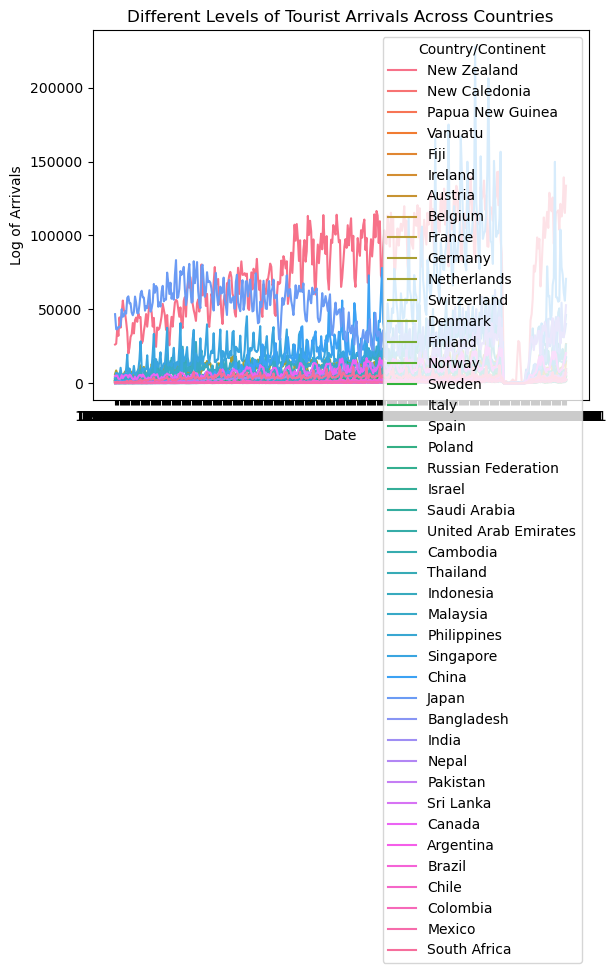

ValueError: Could not interpret value `Exchange` for `y`. An entry with this name does not appear in `data`.

In [224]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=df, x='Date', y='Arrivals', hue='Country/Continent')
plt.title('Different Levels of Tourist Arrivals Across Countries')
plt.ylabel('Log of Arrivals')
plt.show()

sns.lineplot(data=df, x='Date', y='Exchange', hue='Country/Continent')
plt.title('Different Exchange Rate Levels Across Countries')
plt.ylabel('Log Exchange Rate (AUD vs Local)')
plt.show()

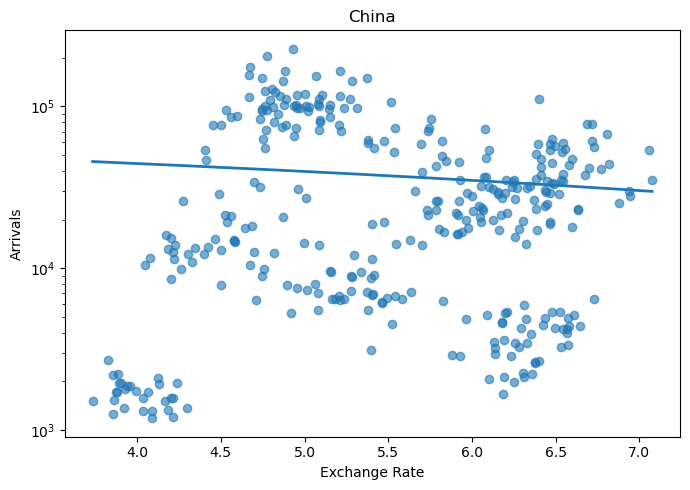

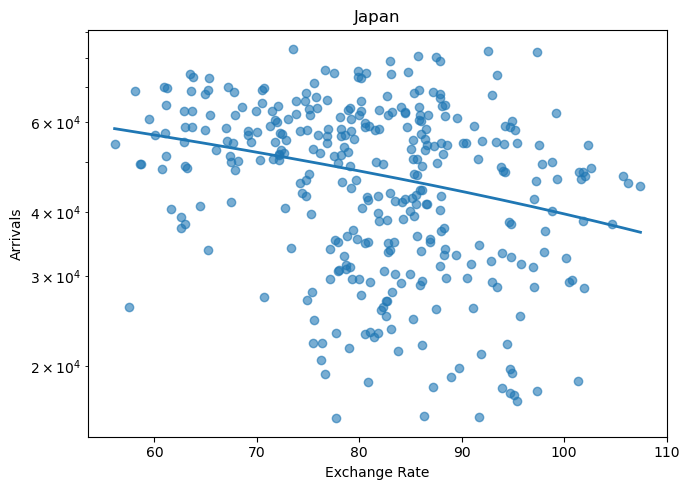

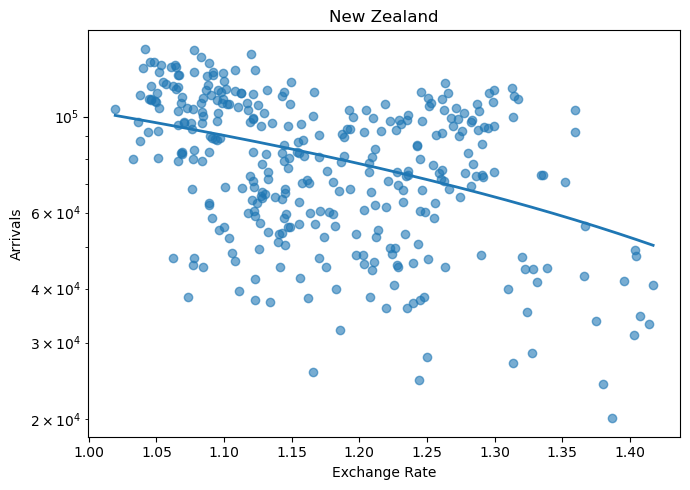

In [262]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats

# ---- inputs ----
countries_to_plot = ['China', 'Japan', 'New Zealand']  # change as needed
xvar = 'Exchange Rate/TWI'   # or use your transformed change: 'd_ln_Exchange'
yvar = 'Arrivals'

# (optional) ensure proper sorting and no missing values
df_plot = (df
           .sort_values(['Country','Date'])
           .dropna(subset=[xvar, yvar])
          )

for c in countries_to_plot:
    d = df_plot[df_plot['Country'] == c].copy()
    if d.empty:
        print(f'No data for {c}, skipping.')
        continue

    # --- compute stats for annotation ---
    X = sm.add_constant(d[xvar].values)
    y = d[yvar].values
    ols_res = sm.OLS(y, X).fit()  # simple OLS (line is the same regardless of robust SEs)
    slope = ols_res.params[1]
    pval  = ols_res.pvalues[1]
    r, _  = stats.pearsonr(d[xvar].values, d[yvar].values)

    # --- fitted line for plotting ---
    xline = np.linspace(d[xvar].min(), d[xvar].max(), 200)
    yline = ols_res.params[0] + slope * xline

    # --- figure (separate plot per country) ---
    plt.figure(figsize=(7,5))
    plt.scatter(d[xvar], d[yvar], alpha=0.6)
    plt.plot(xline, yline, linewidth=2)

    plt.title(f'{c}')
    plt.xlabel("Exchange Rate")
    plt.ylabel(yvar)
    plt.yscale('log')
    plt.tight_layout()

    # (optional) save each plot
    # plt.savefig(f'{c}_{yvar}_vs_{xvar}.png', dpi=150)

    plt.show()

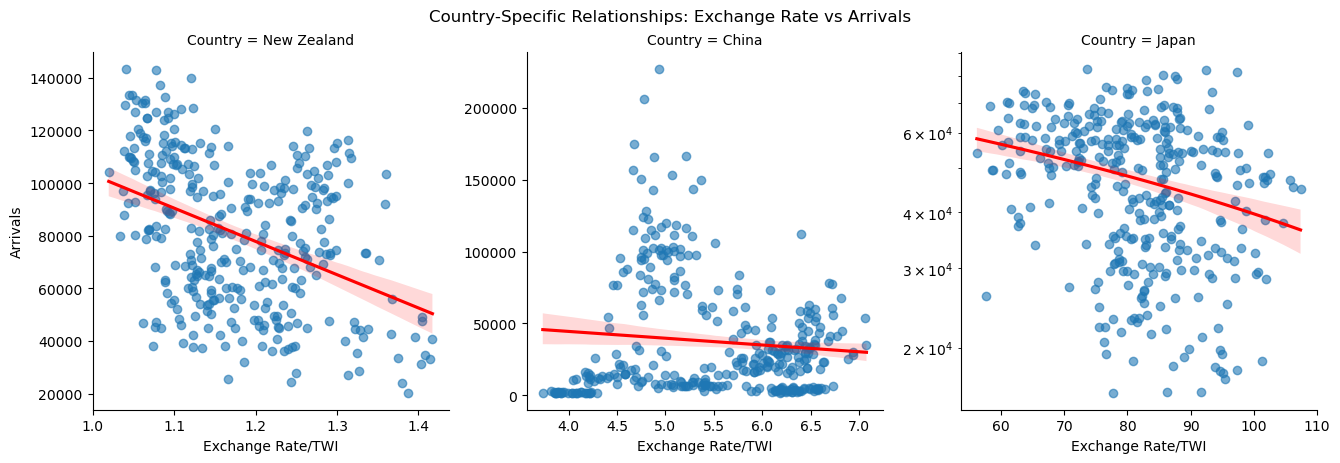

In [266]:
import seaborn as sns
sns.lmplot(
    data=df[df['Country'].isin(['China','Japan','New Zealand'])],
    x='Exchange Rate/TWI', y='Arrivals',
    col='Country', col_wrap=3, height=4.5,
    scatter_kws={'alpha':0.6}, line_kws={'color':'red'},
    facet_kws=dict(sharex=False, sharey=False)
)

plt.suptitle('Country-Specific Relationships: Exchange Rate vs Arrivals', y=1.02)
plt.yscale('log')
#plt.xscale('log')
plt.show()

<Axes: title={'center': 'Average Yearly Arrivals (1991-2025)'}, xlabel='Country/Continent'>

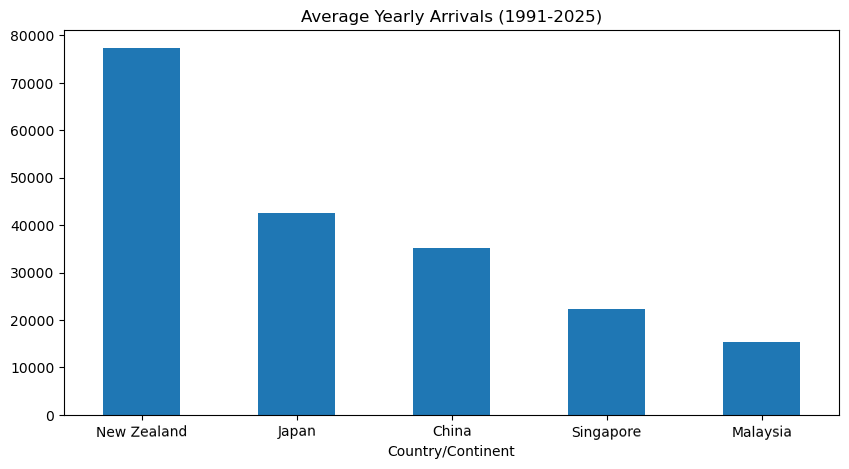

In [251]:
arrivals_fx_df.groupby(["Country/Continent","Date"])["Arrivals"].sum() \
    .groupby("Country/Continent").mean().sort_values(ascending=False)[0:5] \
    .plot.bar(figsize=(10,5), rot=0.5, title="Average Yearly Arrivals (1991-2025)")

In [125]:
arrivals_fx_df[arrivals_fx_df['Country/Continent'] == "Singapore"]

,Country/Continent,Arrivals,gdp_per_capita,gdp,inflation,unemployment,Under 1 week,1 and under 2 weeks,2 weeks and under 1 month,1 and under 2 months,...,Education,Other & not stated,FLTS IN,PAX IN,SEATS IN,FLTS OUT,PAX OUT,SEATS OUT,Exchange Rate/TWI,Date
11424,Singapore,3460,14502.379994,4.546616e+10,3.425702,2.180,0.250648,0.270206,0.173036,0.111205,...,0.055574,0.067072,192.0,50617.0,64896.0,191.0,38898.0,63821.0,1.3588,1991-01-01
11425,Singapore,6940,14502.379994,4.546616e+10,3.425702,2.180,0.228711,0.267852,0.202004,0.125662,...,0.057144,0.061342,171.0,42260.0,56871.0,171.0,33951.0,56849.0,1.3555,1991-02-01
11426,Singapore,6340,14502.379994,4.546616e+10,3.425702,2.180,0.224430,0.305090,0.234579,0.116444,...,0.019505,0.060842,178.0,37255.0,56754.0,179.0,39618.0,57190.0,1.3926,1991-03-01
11427,Singapore,6460,14502.379994,4.546616e+10,3.425702,2.180,0.285060,0.294345,0.184286,0.115714,...,0.024939,0.044759,158.0,33287.0,51361.0,159.0,39159.0,51850.0,1.3842,1991-04-01
11428,Singapore,4750,14502.379994,4.546616e+10,3.425702,2.180,0.330855,0.292875,0.197460,0.080855,...,0.017533,0.053466,164.0,27499.0,53494.0,164.0,31864.0,53394.0,1.3428,1991-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11827,Singapore,41280,90674.066633,5.473866e+11,2.389511,3.182,0.266743,0.327231,0.175896,0.059912,...,0.054599,0.039951,995.0,237386.0,284558.0,1002.0,242815.0,284737.0,0.8869,2024-08-01
11828,Singapore,31370,90674.066633,5.473866e+11,2.389511,3.182,0.248363,0.303858,0.176442,0.077883,...,0.049706,0.040446,975.0,246715.0,280739.0,977.0,257258.0,280337.0,0.8871,2024-09-01
11829,Singapore,34860,90674.066633,5.473866e+11,2.389511,3.182,0.280126,0.286695,0.179035,0.079125,...,0.040935,0.042057,1002.0,273072.0,288064.0,1011.0,240970.0,288125.0,0.8688,2024-10-01
11830,Singapore,39430,90674.066633,5.473866e+11,2.389511,3.182,0.268753,0.279078,0.180655,0.079096,...,0.031120,0.038958,1011.0,259062.0,297089.0,1019.0,272420.0,296985.0,0.8731,2024-11-01


## Fixed Effects Model

Fixed effects model with statsmodels. Removing any NA's for now (or replacing with 0).

In [276]:
import statsmodels.formula.api as smf
from patsy import dmatrix

df = arrivals_fx_df[
    (arrivals_fx_df['Country/Continent'] == "China") | (arrivals_fx_df['Country/Continent'] == "Japan") |
    (arrivals_fx_df['Country/Continent'] == "New Zealand") | (arrivals_fx_df['Country/Continent'] == "Singapore")
].copy()
df = df[df['Date'] < "2020-02-01"]
df.rename(columns={'Country/Continent':'Country'}, inplace=True)
df['Date'] = pd.to_datetime(df['Date'])

# Use a consistent period for time FE (year-month)
df['ym'] = df['Date'].dt.to_period('M').astype(str)   # e.g. '2020-03'

# ------------- 2. Select & clean variables --------------
# Replace or drop rows with missing critical variables
df = df.dropna(subset=['Arrivals', 'Exchange Rate/TWI', 'gdp_per_capita', 'Date'])

# If any Arrivals = 0 (or Exchange = 0), add a small epsilon before log
eps = 1e-6
df['Arrivals_pos'] = df['Arrivals'].clip(lower=0) + eps
df['Exchange_pos'] = df['Exchange Rate/TWI'].clip(lower=0) + eps

# ------------- 3. Create log variables ------------------
df['ln_Arrivals'] = np.log(df['Arrivals_pos'])
df['ln_Exchange'] = np.log(df['Exchange_pos'])

# log controls (where appropriate)
df['ln_gdp_pc'] = np.log(df['gdp_per_capita'].clip(lower=eps))

# optionally log seats or pax in if you want supply control
df['ln_SEATS_IN'] = np.log(df['SEATS IN'].replace(0, np.nan).fillna(eps))
df['ln_PAX_IN'] = np.log(df['PAX IN'].replace(0, np.nan).fillna(eps))

# ------------- 4. (Optional) Additional control vars ----
# Keep non-logged controls as-is (inflation, unemployment)
# If these are proportions, scale appropriately.

# Add lags
df['Exchange_lag1'] = df.groupby('Country')['Exchange Rate/TWI'].shift(1)
df['Exchange_lag3'] = df.groupby('Country')['Exchange Rate/TWI'].shift(3)
df['Exchange_lag6'] = df.groupby('Country')['Exchange Rate/TWI'].shift(6)
df['Exchange_lag12'] = df.groupby('Country')['Exchange Rate/TWI'].shift(12)

df['Inflation_lag1'] = df.groupby('Country')['inflation'].shift(1)
df['Inflation_lag3'] = df.groupby('Country')['inflation'].shift(3)
df['Inflation_lag6'] = df.groupby('Country')['inflation'].shift(6)

df['Gdp_pc_lag1'] = df.groupby('Country')['gdp_per_capita'].shift(1)
df['Gdp_pc_lag3'] = df.groupby('Country')['gdp_per_capita'].shift(3)
df['Gdp_pc_lag6'] = df.groupby('Country')['gdp_per_capita'].shift(6)

df['Gdp_lag1'] = df.groupby('Country')['gdp'].shift(1)
df['Gdp_lag3'] = df.groupby('Country')['gdp'].shift(3)
df['Gdp_lag6'] = df.groupby('Country')['gdp'].shift(6)

# Log the lags
df['ln_Exchange_lag1'] = np.log(df['Exchange_lag1'].clip(lower=eps))
df['ln_Exchange_lag3'] = np.log(df['Exchange_lag3'].clip(lower=eps))
df['ln_Exchange_lag6'] = np.log(df['Exchange_lag6'].clip(lower=eps))
df['ln_Exchange_lag12'] = np.log(df['Exchange_lag12'].clip(lower=eps))

df['ln_Inflation_lag1'] = np.log(df['Inflation_lag1'].clip(lower=eps))
df['ln_Inflation_lag3'] = np.log(df['Inflation_lag3'].clip(lower=eps))
df['ln_Inflation_lag6'] = np.log(df['Inflation_lag6'].clip(lower=eps))

df['ln_Gdp_pc_lag1'] = np.log(df['Gdp_pc_lag1'].clip(lower=eps))
df['ln_Gdp_pc_lag3'] = np.log(df['Gdp_pc_lag3'].clip(lower=eps))
df['ln_Gdp_pc_lag6'] = np.log(df['Gdp_pc_lag6'].clip(lower=eps))

df['ln_Gdp_lag1'] = np.log(df['Gdp_lag1'].clip(lower=eps))
df['ln_Gdp_lag3'] = np.log(df['Gdp_lag3'].clip(lower=eps))
df['ln_Gdp_lag6'] = np.log(df['Gdp_lag6'].clip(lower=eps))

# Get rid of NA's
df = df[df["inflation"].isna() == False]
df = df[df["ln_Exchange_lag1"].isna() == False]
df = df[df["ln_Exchange_lag3"].isna() == False]
df = df[df["ln_Exchange_lag6"].isna() == False]
df = df[df["ln_Exchange_lag12"].isna() == False]

# ------------- 5. Build formula with country & month dummies --------
# Note: patsy / statsmodels will expand C(...) to dummies and drop one to avoid multicollinearity.
formula = "ln_Arrivals ~ ln_Exchange_lag1 + ln_gdp_pc + inflation + unemployment + ln_SEATS_IN + C(Country) + C(ym)"


# ------------- 6. Fit OLS with clustered standard errors (cluster by country) -----
model = smf.ols(formula=formula, data=df).fit(
    cov_type='cluster',
    cov_kwds={'groups': df['Country']}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            ln_Arrivals   R-squared:                       0.935
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                -6.073e+12
Date:                Thu, 09 Oct 2025   Prob (F-statistic):               1.00
Time:                        15:43:18   Log-Likelihood:                 16.622
No. Observations:                1348   AIC:                             656.8
Df Residuals:                    1003   BIC:                             2453.
Df Model:                         344                                         
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

/Users/Justin/anaconda3/envs/data7001/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 344, but rank is 3
  warnings.warn('covariance of constraints does not have full '


### Fixed Effects Model with Linear Models

In [269]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

df['ym'] = df['Date'].dt.to_period('M')
#df['ym'] = df['ym'].to_timestamp()

# set multiindex
df_panel = df.set_index(['Country', 'Date'])

# select dependent & exog
y = df_panel['ln_Arrivals']
X = df_panel[
    [
        'ln_Exchange_lag1', 'ln_Exchange_lag3', 'ln_Exchange_lag6',
        'ln_Gdp_pc_lag1', 'ln_Gdp_pc_lag3', 'ln_Gdp_pc_lag6'
        ,'Inflation_lag1', 'Inflation_lag3', 'Inflation_lag6',
        'unemployment','ln_SEATS_IN']
]
X = sm.add_constant(X)

panel_model = PanelOLS(y, X, entity_effects=True, time_effects=True)
res = panel_model.fit(cov_type='driscoll-kraay', bandwidth=6) #cov_type='driscoll-kraay', bandwidth=6 | cov_kwds={'groups': df['Country']}
print(res.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:            ln_Arrivals   R-squared:                        0.8429
Estimator:                   PanelOLS   R-squared (Between):             -9.7081
No. Observations:                1372   R-squared (Within):               0.5889
Date:                Thu, Oct 09 2025   R-squared (Overall):             -3.1630
Time:                        15:23:05   Log-likelihood                    9.1462
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      495.25
Entities:                           4   P-value                           0.0000
Avg Obs:                       343.00   Distribution:                 F(11,1015)
Min Obs:                       343.00                                           
Max Obs:                       343.00   F-statistic (robust):             577.79
                            

## Dynamic Panel Model

In [270]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

df['ym'] = df['Date'].dt.to_period('M')
#df['ym'] = df['ym'].to_timestamp()

# Create lagged dependent variable
df['ln_Arrivals_lag1'] = df.groupby('Country')['ln_Arrivals'].shift(1)

# set multiindex
df_panel = df.set_index(['Country', 'Date'])

# select dependent & exog
y = df_panel['ln_Arrivals']
X = df_panel[
    [ 
        'ln_Arrivals_lag1',
        'ln_Exchange_lag1', 'ln_Exchange_lag6',
        'ln_Gdp_pc_lag1', 'ln_Gdp_pc_lag6'
        ,'Inflation_lag1', 'Inflation_lag6',
        'unemployment','ln_SEATS_IN']
]
X = sm.add_constant(X)

panel_model = PanelOLS(y, X, entity_effects=True, time_effects=True)
res = panel_model.fit(cov_type='driscoll-kraay', bandwidth=6) #cov_type='driscoll-kraay', bandwidth=6 | cov_kwds={'groups': df['Country']}
print(res.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:            ln_Arrivals   R-squared:                        0.8633
Estimator:                   PanelOLS   R-squared (Between):             -3.3811
No. Observations:                1368   R-squared (Within):               0.7669
Date:                Thu, Oct 09 2025   R-squared (Overall):             -0.7453
Time:                        15:38:42   Log-likelihood                    108.53
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      711.41
Entities:                           4   P-value                           0.0000
Avg Obs:                       342.00   Distribution:                  F(9,1014)
Min Obs:                       342.00                                           
Max Obs:                       342.00   F-statistic (robust):             1431.4
                            

/Users/Justin/anaconda3/envs/data7001/lib/python3.13/site-packages/linearmodels/panel/model.py:1260: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


In [277]:
from linearmodels import PanelOLS
import numpy as np

# Create lagged dependent variable
df['ln_Arrivals_lag1'] = df.groupby('Country')['ln_Arrivals'].shift(1)
panel_df = df.set_index(['Country', 'Date']).copy()

# panel_df = panel_df.dropna(subset=['ln_Arrivals', 'ln_Arrivals_lag1',
#                        'ln_Exchange_lag1', 'ln_Exchange_lag6',
#                        'ln_Gdp_pc_lag1', 'ln_Gdp_pc_lag6',
#                        'Inflation_lag1', 'Inflation_lag6',
#                        'unemployment', 'ln_SEATS_IN'])

# Dynamic FE model
mod = PanelOLS.from_formula(
    'ln_Arrivals ~ ln_Arrivals_lag1 + ln_Exchange_lag1 + ln_Exchange_lag6 + ln_Exchange_lag12'
    '+ ln_Gdp_pc_lag1 + ln_Gdp_pc_lag6 + Inflation_lag1 + Inflation_lag6'
    '+ unemployment + ln_SEATS_IN + EntityEffects + TimeEffects',
    data=panel_df.dropna()
)
#mod = PanelOLS.from_formula('ln_Arrivals ~ ln_Arrivals_lag1 + EntityEffects', data=panel_df)
res = mod.fit(cov_type='driscoll-kraay')
print(res)

                          PanelOLS Estimation Summary                           
Dep. Variable:            ln_Arrivals   R-squared:                        0.8604
Estimator:                   PanelOLS   R-squared (Between):              0.9185
No. Observations:                1344   R-squared (Within):               0.7548
Date:                Thu, Oct 09 2025   R-squared (Overall):              0.9177
Time:                        15:43:45   Log-likelihood                    113.89
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      613.26
Entities:                           4   P-value                           0.0000
Avg Obs:                       336.00   Distribution:                  F(10,995)
Min Obs:                       336.00                                           
Max Obs:                       336.00   F-statistic (robust):             1159.0
                            

In [279]:
# Create lagged dependent variable
df['ln_Arrivals_lag1'] = df.groupby('Country')['ln_Arrivals'].shift(1)

# Add perc changes to exchange rate
df['d_ln_Exchange'] = df.groupby('Country')['ln_Exchange'].diff()
df['d_ln_Exchange_lag1'] = df.groupby('Country')['ln_Exchange_lag1'].diff()
df['d_ln_Exchange_lag3'] = df.groupby('Country')['ln_Exchange_lag3'].diff()
df['d_ln_Exchange_lag6'] = df.groupby('Country')['ln_Exchange_lag6'].diff()

df = df[df["d_ln_Exchange_lag1"].isna() == False]
df = df[df["d_ln_Exchange_lag3"].isna() == False]
df = df[df["d_ln_Exchange_lag6"].isna() == False]


panel_df = df.set_index(['Country', 'Date']).copy()

# panel_df = panel_df.dropna(subset=['ln_Arrivals', 'ln_Arrivals_lag1',
#                        'ln_Exchange_lag1', 'ln_Exchange_lag6',
#                        'ln_Gdp_pc_lag1', 'ln_Gdp_pc_lag6',
#                        'Inflation_lag1', 'Inflation_lag6',
#                        'unemployment', 'ln_SEATS_IN'])

# Dynamic FE model
mod = PanelOLS.from_formula(
    'ln_Arrivals ~ ln_Arrivals_lag1 + ln_Exchange_lag6'
    '+ d_ln_Exchange'
    '+ ln_Gdp_pc_lag1 + ln_Gdp_pc_lag6 + Inflation_lag6'
    '+ unemployment + ln_SEATS_IN + EntityEffects + TimeEffects',
    data=panel_df.dropna()
)
#mod = PanelOLS.from_formula('ln_Arrivals ~ ln_Arrivals_lag1 + EntityEffects', data=panel_df)
res = mod.fit(cov_type='driscoll-kraay')
print(res)

                          PanelOLS Estimation Summary                           
Dep. Variable:            ln_Arrivals   R-squared:                        0.8602
Estimator:                   PanelOLS   R-squared (Between):              0.9194
No. Observations:                1340   R-squared (Within):               0.7573
Date:                Thu, Oct 09 2025   R-squared (Overall):              0.9186
Time:                        15:45:57   Log-likelihood                    114.86
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      764.55
Entities:                           4   P-value                           0.0000
Avg Obs:                       335.00   Distribution:                   F(8,994)
Min Obs:                       335.00                                           
Max Obs:                       335.00   F-statistic (robust):             1391.7
                            

### Independent Country Models

In [213]:
d = df[df['Country'] == 'Japan'].sort_values('Date').copy()

# lags you already built:
# ln_Arrivals, ln_Arrivals_lag1, ln_Exchange_lag1, ln_Exchange_lag6,
# ln_Gdp_pc_lag1, ln_Gdp_pc_lag6, Inflation_lag1, Inflation_lag6,
# unemployment, ln_SEATS_IN

Xcols = ['ln_Arrivals_lag1','ln_Exchange_lag1','ln_Exchange_lag6',
        'ln_Gdp_pc_lag1', #'ln_Gdp_pc_lag6', 'ln_Gdp_pc_lag1',
         'Inflation_lag1','Inflation_lag6',
         'unemployment','ln_SEATS_IN',
        'd_ln_Exchange_lag6']
d = d.dropna(subset=['ln_Arrivals'] + Xcols)

X = sm.add_constant(d[Xcols])
y = d['ln_Arrivals']

# OLS with HAC/Newey–West SEs (choose a sensible maxlags, e.g. 6 or 12 months)
model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 12})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            ln_Arrivals   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     169.6
Date:                Thu, 09 Oct 2025   Prob (F-statistic):          1.82e-118
Time:                        14:12:15   Log-Likelihood:                 83.735
No. Observations:                 342   AIC:                            -147.5
Df Residuals:                     332   BIC:                            -109.1
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.3750      2

## Lag Analysis

In [194]:
df.columns

Index(['Country', 'Arrivals', 'gdp_per_capita', 'gdp', 'inflation',
       'unemployment', 'Under 1 week', '1 and under 2 weeks',
       '2 weeks and under 1 month', '1 and under 2 months',
       '2 and under 3 months', '3 and under 6 months', '6 and under 12 months',
       'Convention/conference', 'Business', 'Visiting friends/relatives',
       'Holiday', 'Employment', 'Education', 'Other & not stated', 'FLTS IN',
       'PAX IN', 'SEATS IN', 'FLTS OUT', 'PAX OUT', 'SEATS OUT',
       'Exchange Rate/TWI', 'Date', 'ym', 'Arrivals_pos', 'Exchange_pos',
       'ln_Arrivals', 'ln_Exchange', 'ln_gdp_pc', 'ln_SEATS_IN', 'ln_PAX_IN',
       'Exchange_lag1', 'Exchange_lag3', 'Exchange_lag6', 'Inflation_lag1',
       'Inflation_lag3', 'Inflation_lag6', 'Gdp_pc_lag1', 'Gdp_pc_lag3',
       'Gdp_pc_lag6', 'Gdp_lag1', 'Gdp_lag3', 'Gdp_lag6', 'ln_Exchange_lag1',
       'ln_Exchange_lag3', 'ln_Exchange_lag6', 'ln_Inflation_lag1',
       'ln_Inflation_lag3', 'ln_Inflation_lag6', 'ln_Gdp_pc_lag1',

In [214]:
import pandas as pd

# Sort by entity and time to ensure proper lagging
lag_df = df.sort_values(['Country', 'Date']).copy()

# Specify which variables you want lags for and how many
variables_to_lag = ['ln_Arrivals', 'ln_Exchange', 'ln_gdp_pc', 'inflation','d_ln_Exchange']
max_lag = 12  # e.g. 12 months

# Create lag columns for each variable
for var in variables_to_lag:
    for lag in range(1, max_lag + 1):
        lag_df[f'{var}_lag{lag}'] = lag_df.groupby('Country')[var].shift(lag)

# Drop rows with missing lags at the start of each country’s time series
lag_df = lag_df.dropna().reset_index(drop=True)

print(df.filter(regex='ln_Exchange').head(10))

    ln_Exchange  ln_Exchange_lag1  ln_Exchange_lag3  ln_Exchange_lag6  \
7      0.312619          0.308367          0.265130          0.270409   
8      0.339255          0.312619          0.285404          0.277783   
9      0.339824          0.339254          0.308367          0.287132   
10     0.333540          0.339824          0.312619          0.265130   
11     0.342029          0.333539          0.339254          0.285404   
12     0.327144          0.342028          0.339824          0.308367   
13     0.321939          0.327143          0.333539          0.312619   
14     0.338756          0.321939          0.342028          0.339254   
15     0.346565          0.338755          0.327143          0.339824   
16     0.348684          0.346564          0.321939          0.333539   

    d_ln_Exchange  d_ln_Exchange_lag1  d_ln_Exchange_lag3  d_ln_Exchange_lag6  
7        0.004252            0.022962           -0.022002            0.001909  
8        0.026636            0.00425

In [220]:
countries = df['Country'].unique()
max_lag = 12
results = []

for country in countries:
    d = lag_df[lag_df['Country'] == country].dropna()
    for lag in range(1, max_lag + 1):
        y = d['ln_Arrivals']
        X = sm.add_constant(pd.DataFrame({
            'ln_Arrivals_lag1': d['ln_Arrivals_lag1'],
            'd_ln_Exchange_lag': d[f'd_ln_Exchange_lag{lag}'],
            'ln_SEATS_IN': d['ln_SEATS_IN']
        }))
        model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
        results.append({
            'Country': country,
            'Lag': lag,
            'Coeff': model.params['d_ln_Exchange_lag'],
            'pval': model.pvalues['d_ln_Exchange_lag']
        })

lag_results = pd.DataFrame(results)
lag_results

,Country,Lag,Coeff,pval
0,New Zealand,1,0.549524,0.201388
1,New Zealand,2,0.579330,0.145520
2,New Zealand,3,0.018092,0.967411
3,New Zealand,4,-0.044801,0.906497
4,New Zealand,5,0.375290,0.423368
5,New Zealand,6,0.123718,0.756561
6,New Zealand,7,-0.307773,0.387151
7,New Zealand,8,0.401779,0.404124
8,New Zealand,9,-0.093334,0.822124
9,New Zealand,10,-0.348414,0.387399


In [221]:
# Get most significant lags
# Find lag with lowest p-value per country
sig_lags = (
    lag_results.groupby('Country')
    .apply(lambda x: x.loc[x['pval'].idxmin(), ['Lag', 'Coeff', 'pval']])
    .reset_index()
)
print(sig_lags)

       Country  Lag     Coeff      pval
0        China    2 -0.678967  0.056404
1        Japan    8  0.523377  0.030530
2  New Zealand    2  0.579330  0.145520
3    Singapore    7 -0.886340  0.227627


/var/folders/xs/zddv9w2s69q__3dnkcd4533h0000gn/T/ipykernel_48327/1443309573.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.loc[x['pval'].idxmin(), ['Lag', 'Coeff', 'pval']])


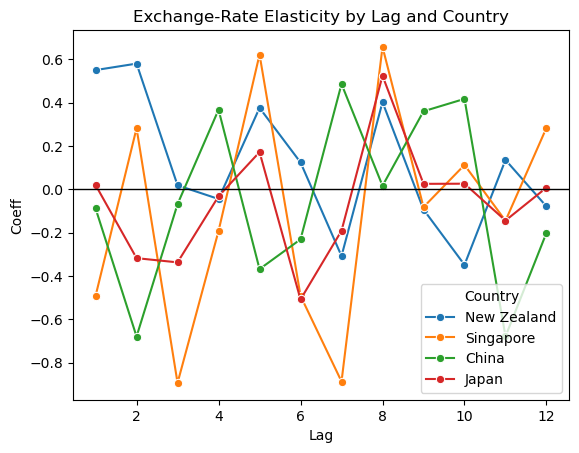

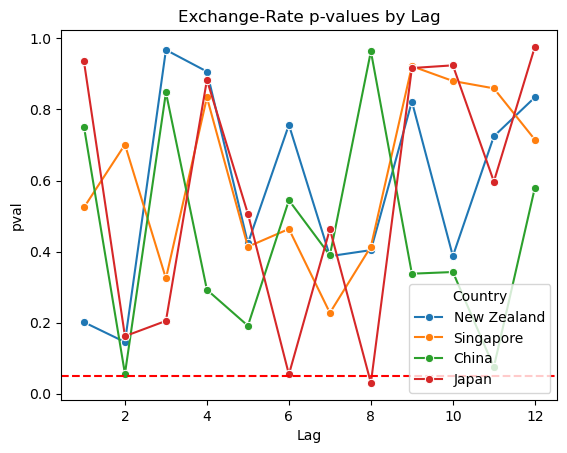

In [222]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=lag_results, x='Lag', y='Coeff', hue='Country', marker='o')
plt.title('Exchange-Rate Elasticity by Lag and Country')
plt.axhline(0, color='black', lw=1)
plt.show()

sns.lineplot(data=lag_results, x='Lag', y='pval', hue='Country', marker='o')
plt.title('Exchange-Rate p-values by Lag')
plt.axhline(0.05, color='red', linestyle='--')
plt.show()

In [189]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only your independent variables (no dependent variable)
Xcols = ['ln_Arrivals_lag1','ln_Exchange_lag1','ln_Exchange_lag6',
         'ln_Gdp_pc_lag1','ln_Gdp_pc_lag6','Inflation_lag1','Inflation_lag6',
         'unemployment','ln_SEATS_IN']

X = sm.add_constant(d[Xcols])  # 'd' is your country-specific dataframe
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data)

           Variable           VIF
0             const  30687.851649
1  ln_Arrivals_lag1      3.447755
2  ln_Exchange_lag1      2.531335
3  ln_Exchange_lag6      3.257974
4    ln_Gdp_pc_lag1      5.032472
5    ln_Gdp_pc_lag6      4.765326
6    Inflation_lag1      3.855689
7    Inflation_lag6      3.470693
8      unemployment      2.352288
9       ln_SEATS_IN      3.714407


## Cross Correlation Analysis

F-Statistic for statsmodel Fixed Effects model is 

In [144]:
def cross_correlation_lags(series_x, series_y, max_lag=12):
    """
    Compute cross-correlation between two time series for lags up to +/- max_lag
    """
    lags = range(0, max_lag + 1)
    corr = [series_x.corr(series_y.shift(l)) for l in lags]
    return pd.DataFrame({'Lag': lags, 'Correlation': corr})

# Prepare series 
china = df.sort_values('Date').copy() #[df['Country'] == 'China']

# Compute first differences of logs
china['dln_Arrivals'] = china.groupby("Country")['ln_Arrivals'].diff()
china['dln_Exchange'] = china.groupby("Country")['ln_Exchange'].diff()

# Drop first row (has NaN after differencing)
china = china.dropna(subset=['dln_Arrivals', 'dln_Exchange'])

result = cross_correlation_lags(
    china['dln_Arrivals'], china['dln_Exchange'], max_lag=12
)

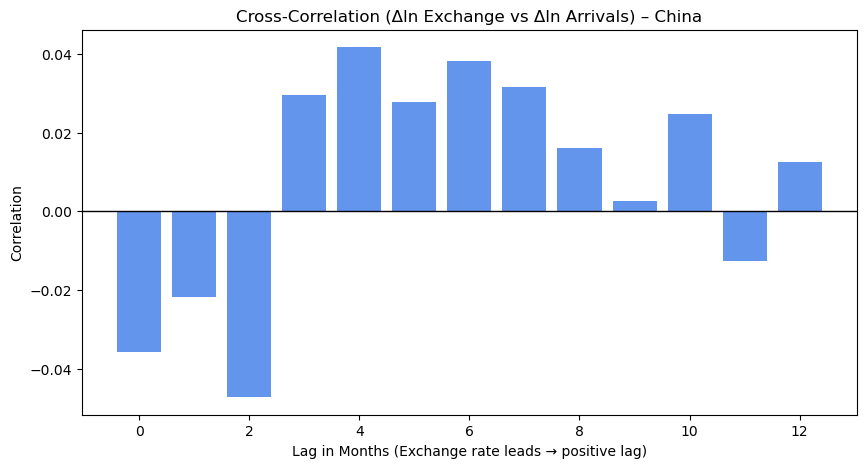

In [145]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(result['Lag'], result['Correlation'], color='cornflowerblue')
plt.axhline(0, color='black', linewidth=1)
plt.title('Cross-Correlation (Δln Exchange vs Δln Arrivals) – China')
plt.xlabel('Lag in Months (Exchange rate leads → positive lag)')
plt.ylabel('Correlation')
plt.show()

### Cross Correlation Function Analysis

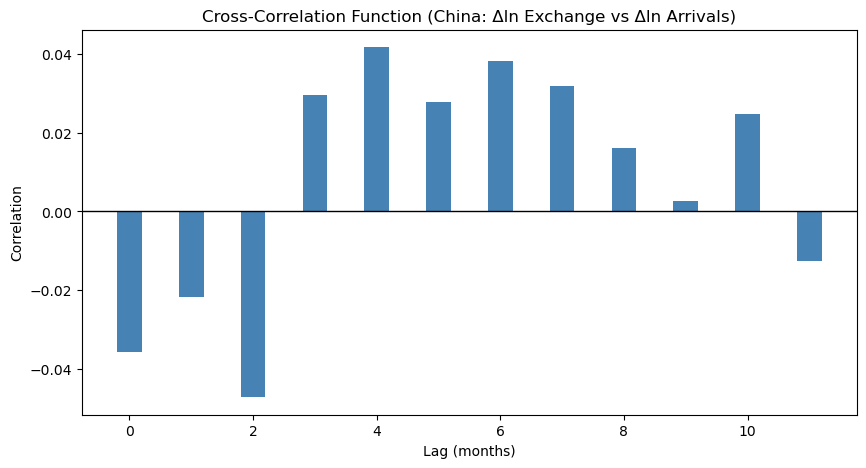

In [146]:
from statsmodels.tsa.stattools import ccf
# Compute up to N lags
lags = 12  # months, for example
ccf_vals = ccf(china['dln_Arrivals'], china['dln_Exchange'])[:lags]

# Plot CCF
plt.figure(figsize=(10,5))
plt.bar(range(lags), ccf_vals, width=0.4, color='steelblue')
plt.axhline(0, color='black', linewidth=1)
plt.title('Cross-Correlation Function (China: Δln Exchange vs Δln Arrivals)')
plt.xlabel('Lag (months)')
plt.ylabel('Correlation')
plt.show()

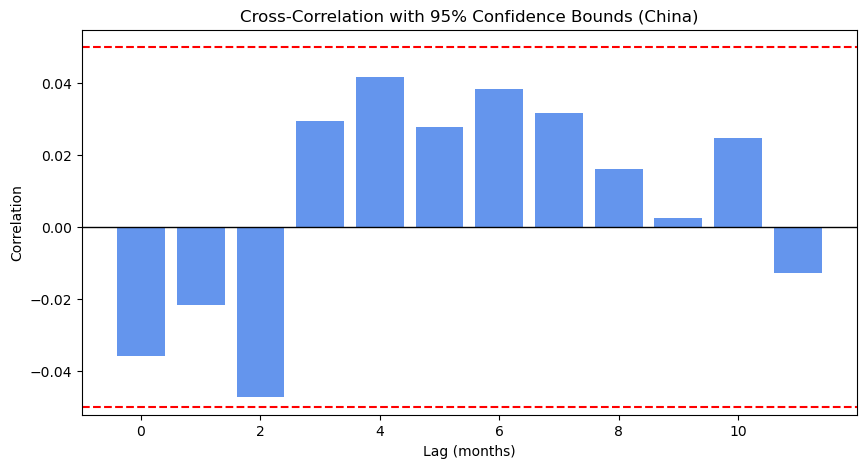

In [147]:
n = len(china)
conf = 2 / np.sqrt(n)
plt.figure(figsize=(10,5))
plt.bar(range(lags), ccf_vals, color='cornflowerblue')
plt.axhline( conf, color='red', linestyle='--')
plt.axhline(-conf, color='red', linestyle='--')
plt.axhline(0, color='black', linewidth=1)
plt.title('Cross-Correlation with 95% Confidence Bounds (China)')
plt.xlabel('Lag (months)')
plt.ylabel('Correlation')
plt.show()

In [120]:
significant_lag = np.argmax(np.abs(ccf_vals))
print(f"The most significant lag is {significant_lag} months with correlation {ccf_vals[significant_lag]:.3f}")

The most significant lag is 8 months with correlation 0.098


In [115]:
# For all countries
test_df = df.copy()
results = []
for country, d in test_df.groupby('Country'):
    # Compute first differences of logs
    d['dln_Arrivals'] = d['ln_Arrivals'].diff()
    d['dln_Exchange'] = d['ln_Exchange'].diff()
    d = d.dropna(subset=['dln_Arrivals', 'dln_Exchange'])
    ccf_vals = ccf(d['dln_Arrivals'], d['dln_Exchange'])[:12]
    lag = np.argmax(np.abs(ccf_vals))
    results.append({'Country': country, 'BestLag': lag, 'Corr': ccf_vals[lag]})

summary = pd.DataFrame(results)
print(summary)

       Country  BestLag      Corr
0        China        0 -0.055700
1        Japan        8  0.097714
2  New Zealand        1  0.094841
